# FerroMobile — Visualisations spatiales et QoS

Corridor Courpière → Ambert, ligne 785000 (~38.6 km).

**Contenu**
1. Carte du corridor (trajet, antennes déduplicées, tunnels, zones blanches)
2. Débit en fonction de la distance (une figure par techno + synthèse)
3. QoS le long du corridor (qos1 par techno, qos2 par techno, overlaps)

## Setup

In [94]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import LineString

plt.rcParams["figure.dpi"] = 100

BASE_DIR = os.path.dirname(os.getcwd())
DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "dataset_enrichi.csv")
# Fallback si le notebook est lancé depuis un autre endroit
if not os.path.exists(DATASET_PATH):
    for alt in ["data/processed/dataset_enrichi.csv", "dataset_enrichi.csv"]:
        if os.path.exists(alt):
            DATASET_PATH = alt
            break

df = pd.read_csv(DATASET_PATH, low_memory=False)
df.shape

(87600, 63)

In [95]:
# Palettes
COLORS_OP = {
    "ORANGE":           "#FF6600",
    "SFR":              "#CC0000",
    "BOUYGUES TELECOM": "#009FE3",
    "FREE MOBILE":      "#00A651",
}
COLORS_TECH  = {"2G": "#d62728", "3G": "#ff7f0e", "4G": "#2ca02c", "5G": "#1f77b4"}
MARKERS_GEN  = {"2G": "o", "3G": "s", "4G": "^", "5G": "D"}

# Seuils du pipeline (voir doc dataset et enrich_data.py)
# - SEUIL_ZONE_BLANCHE : couverture minimale, celui utilisé pour calculer zone_blanche
# - SEUIL_QOS         : seuil de satisfaction QoS pour qos_sat_debit (référence ARCEP navigation)
SEUIL_ZONE_BLANCHE = 1.0  # Mbps — DEBIT_VIABLE_MBPS dans enrich_data.py
SEUIL_QOS          = 3.0  # Mbps — DEBIT_MIN_MBPS dans enrich_data.py

SCENARIO = "S3"          # scénario par défaut (orage été)
df_s = df[df["scenario_id"] == SCENARIO]

## 1. Carte du corridor

Trajet en vert (couvert) / rouge (zone blanche, < 5 Mb/s), tunnels en gris, antennes colorées par opérateur et de forme selon la technologie. Les antennes co-localisées sont éclatées en petite orbite pour éviter la superposition.

In [96]:
# Voie : point_id -> (lat, lon, distance, tunnel, meilleur débit toutes technos)
voie = df_s.groupby("point_id").agg(
    lat=("lat","first"), lon=("lon","first"),
    distance_km=("distance_km","first"),
    in_tunnel=("in_tunnel","first"),
    best_debit=("debit_adj_mbps","max"),
).reset_index().sort_values("distance_km").reset_index(drop=True)

# 0 = couvert, 1 = zone blanche, 2 = tunnel
voie["etat"] = np.where(voie["in_tunnel"], 2,
                np.where(voie["best_debit"] < SEUIL_ZONE_BLANCHE, 1, 0))

tun_pts = voie[voie["in_tunnel"]]
voie["etat"].value_counts().to_dict()

{0: 1335, 1: 417, 2: 171}

In [97]:
# Antennes uniques (une ligne par ant_id) puis déduplication géographique
ant_raw = (df[df["ant_id"].notna()]
           .groupby("ant_id")
           .agg(ant_lat=("ant_lat","first"), ant_lon=("ant_lon","first"),
                operateur=("operateur","first"), generation=("generation","first"))
           .reset_index())

# Regroupe les antennes qui partagent le même emplacement (~100 m près)
ant_raw["pos_key"] = (ant_raw["ant_lat"].round(3).astype(str) + "_" +
                      ant_raw["ant_lon"].round(3).astype(str))
antennes = (ant_raw.groupby(["pos_key","operateur","generation"], as_index=False)
                   .agg(ant_lat=("ant_lat","first"), ant_lon=("ant_lon","first")))
print(f"{len(ant_raw)} antennes brutes -> {len(antennes)} marqueurs dédupliqués")

204 antennes brutes -> 137 marqueurs dédupliqués


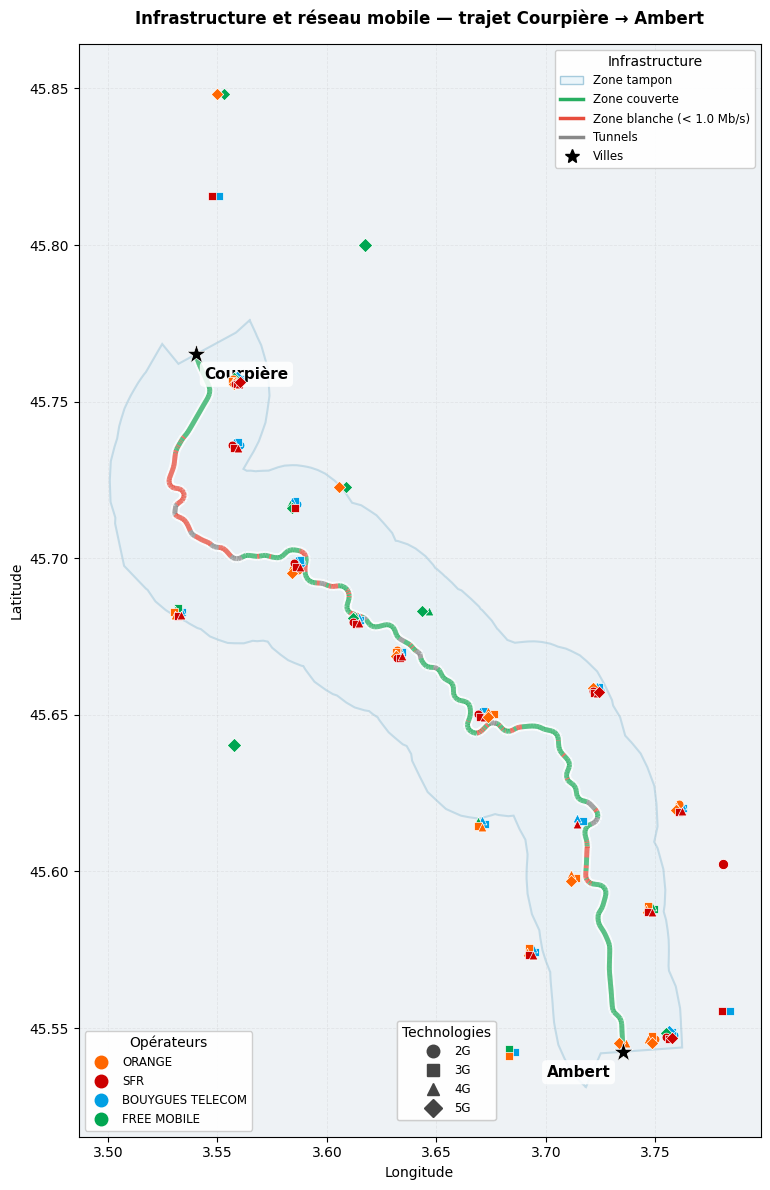

In [98]:
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("#eef2f5")

# Ratio d'aspect géographique : ~ cos(lat) pour éviter la déformation
lat_mean = voie["lat"].mean()
ax.set_aspect(1.0 / np.cos(np.radians(lat_mean)))

# --- Zone tampon 3 km autour du trajet ---
RAYON_KM = 3.0
buffer_deg = RAYON_KM / 111
ligne_geom  = LineString(list(zip(voie["lon"], voie["lat"])))
zone_tampon = ligne_geom.buffer(buffer_deg, cap_style=2, join_style=2, resolution=8)

polys = zone_tampon.geoms if zone_tampon.geom_type == "MultiPolygon" else [zone_tampon]
for poly in polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor="#daeef8", edgecolor="#5a9fc0",
            lw=1.5, alpha=0.28, zorder=1)

# --- Voie ferrée : segment par segment, couleur selon état ---
COLOR_ETAT = {0: "#27ae60", 1: "#e74c3c", 2: "#888888"}
for i in range(len(voie) - 1):
    r1, r2 = voie.iloc[i], voie.iloc[i+1]
    color = COLOR_ETAT[r1["etat"]]
    ax.plot([r1["lon"], r2["lon"]], [r1["lat"], r2["lat"]],
            color="white", lw=6.5, zorder=2, solid_capstyle="butt")
    ax.plot([r1["lon"], r2["lon"]], [r1["lat"], r2["lat"]],
            color=color, lw=3.5, zorder=3, solid_capstyle="butt")

# --- Antennes : éclatement en orbite si plusieurs au même endroit ---
aspect  = np.cos(np.radians(lat_mean))
R_ORBIT = 0.0012

for pos_key, group in antennes.groupby("pos_key"):
    clat, clon = group["ant_lat"].iloc[0], group["ant_lon"].iloc[0]
    n = len(group)
    if n == 1:
        row = group.iloc[0]
        ax.scatter(clon, clat, marker=MARKERS_GEN[row["generation"]],
                   color=COLORS_OP.get(row["operateur"], "#888"),
                   s=55, zorder=6, edgecolors="white", linewidths=0.6)
    else:
        ax.scatter(clon, clat, marker="+", color="#777", s=25, zorder=5, linewidths=0.8)
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        for idx, (_, row) in enumerate(group.iterrows()):
            orb_lon = clon + (R_ORBIT/aspect) * np.cos(angles[idx])
            orb_lat = clat + R_ORBIT * np.sin(angles[idx])
            ax.plot([clon, orb_lon], [clat, orb_lat],
                    color="#ccc", lw=0.5, zorder=4, alpha=0.4)
            ax.scatter(orb_lon, orb_lat, marker=MARKERS_GEN[row["generation"]],
                       color=COLORS_OP.get(row["operateur"], "#888"),
                       s=40, zorder=6, edgecolors="white", linewidths=0.5)

# --- Villes ---
for ville, i, offset in [("Courpière", 0, (6,-18)), ("Ambert", -1, (-55,-18))]:
    lat, lon = voie.iloc[i]["lat"], voie.iloc[i]["lon"]
    ax.scatter(lon, lat, marker="*", color="black", s=220, zorder=8,
               edgecolors="white", linewidths=0.5)
    ax.annotate(ville, (lon, lat), textcoords="offset points", xytext=offset,
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))

# --- Légendes séparées ---
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor="#daeef8", edgecolor="#5a9fc0", label="Zone tampon", alpha=0.5),
    Line2D([0],[0], color="#27ae60", lw=2.5, label="Zone couverte"),
    Line2D([0],[0], color="#e74c3c", lw=2.5, label=f"Zone blanche (< {SEUIL_ZONE_BLANCHE} Mb/s)"),
    Line2D([0],[0], color="#888888", lw=2.5, label="Tunnels"),
    Line2D([0],[0], marker="*", color="black", linestyle="None", markersize=10, label="Villes"),
], title="Infrastructure", loc="upper right", fontsize=8.5, framealpha=0.95)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[
    Line2D([0],[0], marker="o", color=c, linestyle="None", markersize=9, label=op)
    for op, c in COLORS_OP.items()
], title="Opérateurs", loc="lower left", fontsize=8.5, framealpha=0.95)
ax.add_artist(leg2)

leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color="#444", linestyle="None", markersize=9, label=gen)
    for gen, m in MARKERS_GEN.items()
], title="Technologies", loc="lower right", bbox_to_anchor=(0.62, 0.01),
   fontsize=8.5, framealpha=0.95)
ax.add_artist(leg3)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Infrastructure et réseau mobile — trajet Courpière → Ambert",
             fontweight="bold", pad=14)
ax.grid(True, alpha=0.2, linestyle="--", lw=0.6)
plt.tight_layout(); plt.show()

## 2. Débit en fonction de la distance

**Principe** : chaque technologie a un ordre de grandeur de débit très différent (2G ~0.2 Mbps, 5G ~350 Mbps). Les tracer sur un même axe log rend certaines courbes plates. On sépare donc en :
- **une figure par techno avec son échelle linéaire propre**, pour voir les vraies variations
- **une figure de synthèse** qui montre quelle techno domine à chaque point du corridor

### 2.a Préparation des données

In [99]:
cel = df_s[df_s["generation"].isin(["2G","3G","4G","5G"]) & (~df_s["in_tunnel"])]

# Meilleur débit par (point, techno) — la meilleure antenne de chaque techno gagne
best_debit = cel.groupby(["point_id","generation"])["debit_adj_mbps"].max().unstack()
best_debit = best_debit.reindex(voie["point_id"].values)
best_debit["distance_km"] = voie["distance_km"].values

# Lissage glissant ~500 m pour retirer le bruit point à point
window = 25
for gen in ["2G","3G","4G","5G"]:
    if gen in best_debit.columns:
        best_debit[f"{gen}_smooth"] = best_debit[gen].rolling(window, min_periods=1).mean()

best_debit.head()

generation,2G,3G,4G,5G,distance_km,2G_smooth,3G_smooth,4G_smooth,5G_smooth
point_id,,,,,,,,,
0,0.24,1.6165,37.8800,102.1673,0.00,0.24,1.616500,37.880000,102.167300
1,0.24,1.7680,37.9163,102.5963,0.02,0.24,1.692250,37.898150,102.381800
2,0.24,2.0034,37.9519,103.0178,0.04,0.24,1.795967,37.916067,102.593800
3,0.24,2.2506,37.9876,103.4363,0.06,0.24,1.909625,37.933950,102.804425
4,0.24,1.5264,38.0220,103.8427,0.08,0.24,1.832980,37.951560,103.012080


### 2.b Une figure par technologie (échelle linéaire adaptée)

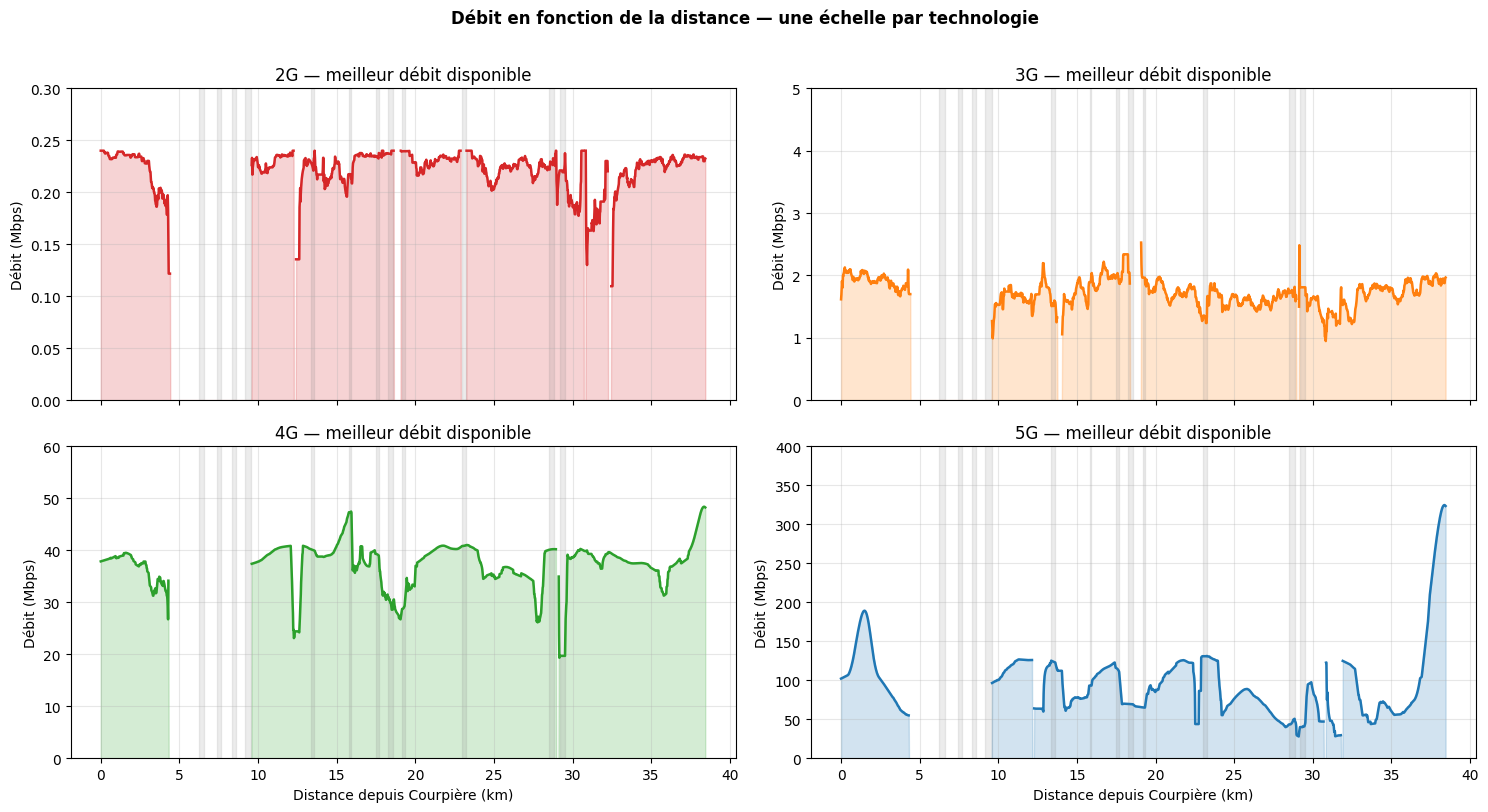

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

# Bornes physiques par techno (documentées dans TECH_PROFILES du pipeline)
Y_MAX = {"2G": 0.3, "3G": 5.0, "4G": 60.0, "5G": 400.0}

for ax, gen in zip(axes.flat, ["2G","3G","4G","5G"]):
    if f"{gen}_smooth" in best_debit.columns:
        ax.plot(best_debit["distance_km"], best_debit[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=1.8)
        ax.fill_between(best_debit["distance_km"], 0,
                        best_debit[f"{gen}_smooth"].fillna(0),
                        color=COLORS_TECH[gen], alpha=0.2)

    # Tunnels
    for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
        ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
                   color="gray", alpha=0.15)

    ax.set_ylim(0, Y_MAX[gen])
    ax.set_title(f"{gen} — meilleur débit disponible")
    ax.set_ylabel("Débit (Mbps)")
    if gen in ["4G", "5G"]:
        ax.set_xlabel("Distance depuis Courpière (km)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Débit en fonction de la distance — une échelle par technologie",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

**Lecture des 4 sous-figures**

- **2G** : débit très stable autour de 0.24 Mbps (proche du maximum théorique GPRS de la table `TECH_PROFILES`). Les petites baisses ponctuelles autour de 30 km sont dues à des points où la meilleure antenne 2G est très éloignée. Utilisable pour de la télémétrie seulement.
- **3G** : plateau autour de 2 Mbps sur presque toute la ligne, avec quelques oscillations entre 1 et 3 Mbps. Suffisant pour de la voix et un data basique.
- **4G** : plateau très élevé entre 35 et 45 Mbps sur tout le corridor. C'est la seule technologie qui offre une couverture haute qualité continue.
- **5G** : présente aux extrémités du corridor et par intermittence au milieu, avec des pics jusqu'à ~330 Mbps près des antennes, mais des trous marqués là où aucune antenne 5G n'est en portée.

**Bandes grises** : tunnels — toutes les technos y sont indisponibles simultanément.

### 2.c Synthèse — quelle techno domine à chaque endroit

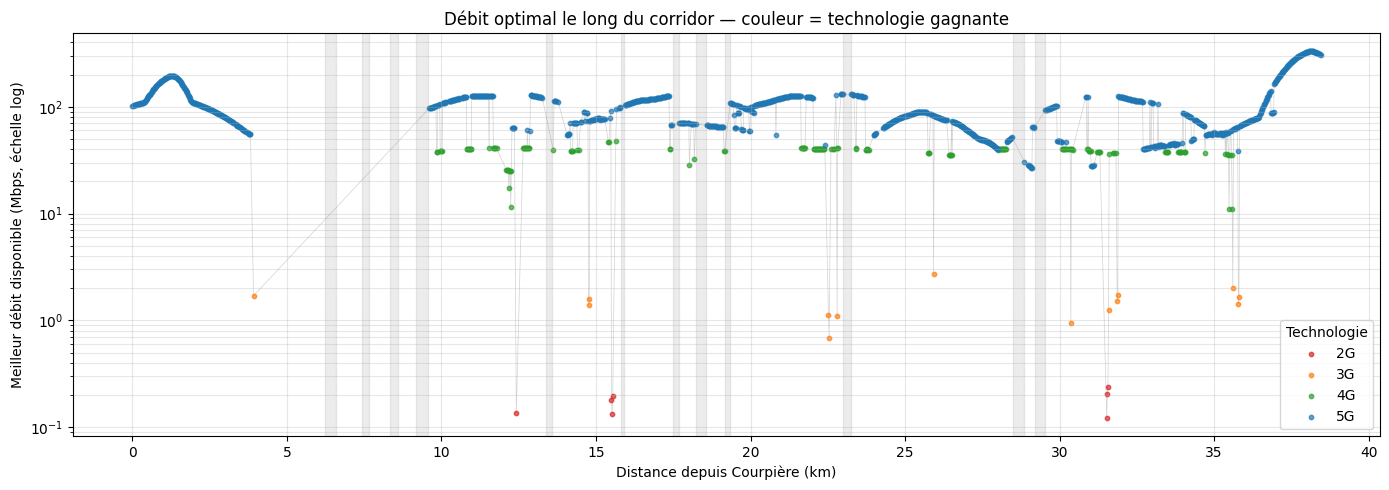


Répartition de la techno gagnante (débit) sur le corridor :
5G    86.2
4G    12.2
3G     1.0
2G     0.5 %


In [101]:
# Pour chaque point, on identifie la meilleure techno disponible
tech_cols = [c for c in ["2G","3G","4G","5G"] if c in best_debit.columns]

# Filtre les lignes où toutes les valeurs sont NaN (points orphelins)
mask_any  = best_debit[tech_cols].notna().any(axis=1)
best_tech = best_debit.loc[mask_any, tech_cols].idxmax(axis=1)
best_val  = best_debit.loc[mask_any, tech_cols].max(axis=1)
dist_ok   = best_debit.loc[mask_any, "distance_km"]

fig, ax = plt.subplots(figsize=(14, 5))

# Enveloppe grise en fond pour montrer la continuité
ax.plot(dist_ok, best_val, color="lightgray", lw=0.5, zorder=0)

# Points colorés selon la techno gagnante
for gen in tech_cols:
    mask = best_tech == gen
    ax.scatter(dist_ok[mask], best_val[mask],
               color=COLORS_TECH[gen], s=10, alpha=0.7, label=gen)

# Tunnels
for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("Meilleur débit disponible (Mbps, échelle log)")
ax.set_title("Débit optimal le long du corridor — couleur = technologie gagnante")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Récap chiffré
print("\nRépartition de la techno gagnante (débit) sur le corridor :")
print((best_tech.value_counts(normalize=True) * 100).round(1).to_string() + " %")

**Lecture de la synthèse**

- La **5G gagne à 86 % des points** couverts par au moins une techno — dès qu'elle est disponible, son débit est imbattable (100 à 350 Mbps).
- La **4G reprend le relais dans 12 % des cas**, principalement là où aucune 5G n'est en portée. Son débit typique de ~40 Mbps reste très confortable.
- La **3G et 2G ne dominent que dans 1.5 % des cas** — ce sont des points isolés, généralement en bordure de zone blanche, où c'est la seule couverture disponible.
- Les bandes grises sont les tunnels : aucune techno ne les couvre, ce qui explique les discontinuités visuelles.

## 3. QoS le long du corridor

Quatre figures dans l'ordre demandé :
1. qos1 — une sous-figure par techno
2. qos2 — une sous-figure par techno
3. qos1 — overlap toutes technos
4. qos2 — overlap toutes technos

In [102]:
# Meilleur qos1/qos2 par (point, techno)
best_q1 = cel.groupby(["point_id","generation"])["qos1"].max().unstack()
best_q2 = cel.groupby(["point_id","generation"])["qos2"].max().unstack()
best_q1 = best_q1.reindex(voie["point_id"].values)
best_q2 = best_q2.reindex(voie["point_id"].values)
best_q1["distance_km"] = voie["distance_km"].values
best_q2["distance_km"] = voie["distance_km"].values

# Lissage
for gen in ["2G","3G","4G","5G"]:
    if gen in best_q1.columns:
        best_q1[f"{gen}_smooth"] = best_q1[gen].rolling(window, min_periods=1).mean()
    if gen in best_q2.columns:
        best_q2[f"{gen}_smooth"] = best_q2[gen].rolling(window, min_periods=1).mean()

### 3.a qos1 — une sous-figure par technologie

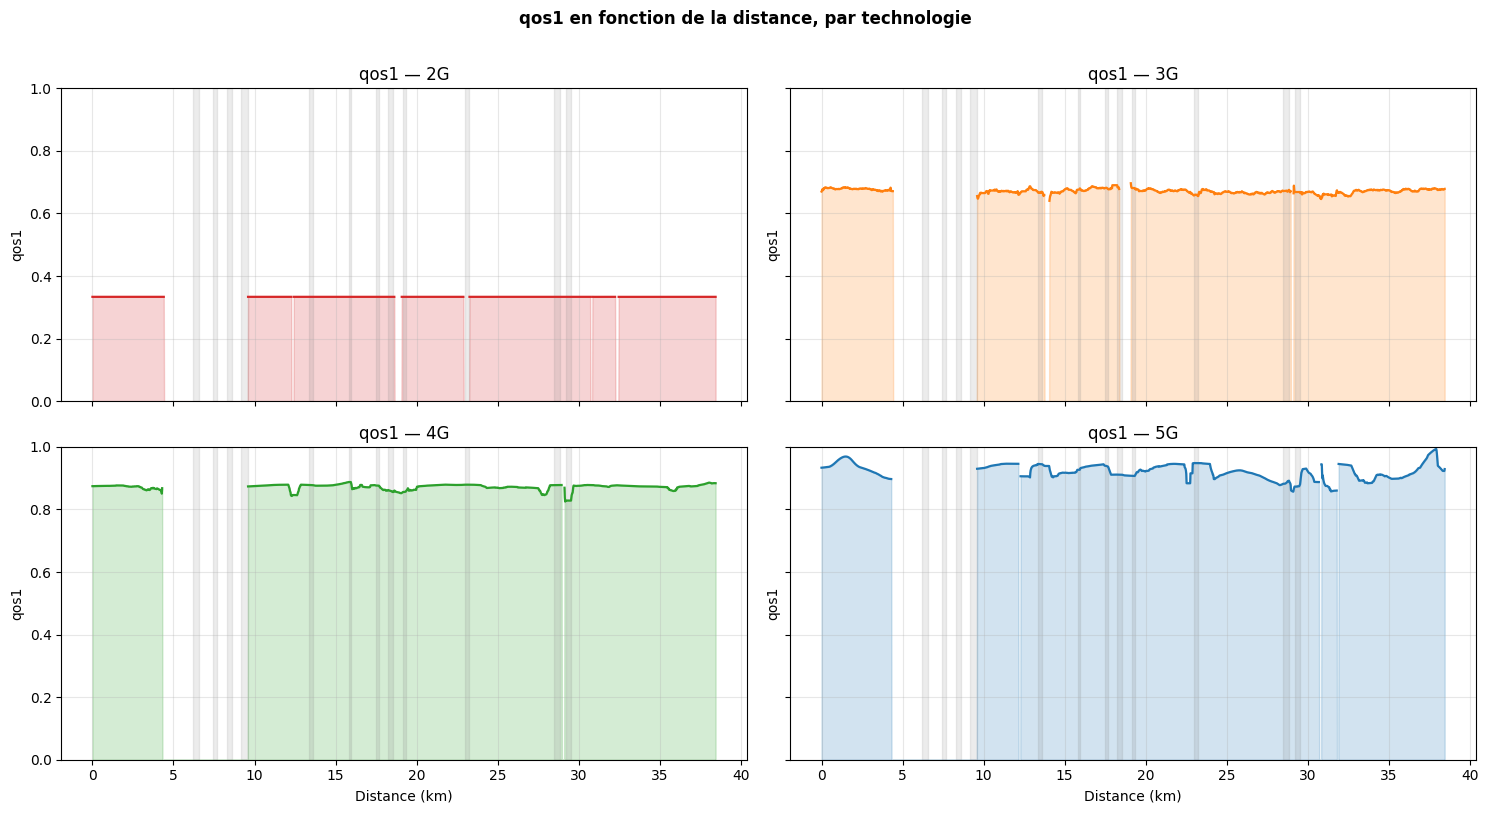

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

for ax, gen in zip(axes.flat, ["2G","3G","4G","5G"]):
    if f"{gen}_smooth" in best_q1.columns:
        ax.plot(best_q1["distance_km"], best_q1[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=1.6)
        ax.fill_between(best_q1["distance_km"], 0,
                        best_q1[f"{gen}_smooth"].fillna(0),
                        color=COLORS_TECH[gen], alpha=0.2)
    for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
        ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
                   color="gray", alpha=0.15)
    ax.set_ylim(0, 1)
    ax.set_title(f"qos1 — {gen}")
    ax.set_ylabel("qos1")
    if gen in ["4G","5G"]:
        ax.set_xlabel("Distance (km)")
    ax.grid(True, alpha=0.3)

plt.suptitle("qos1 en fonction de la distance, par technologie",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 3.b qos2 — une sous-figure par technologie

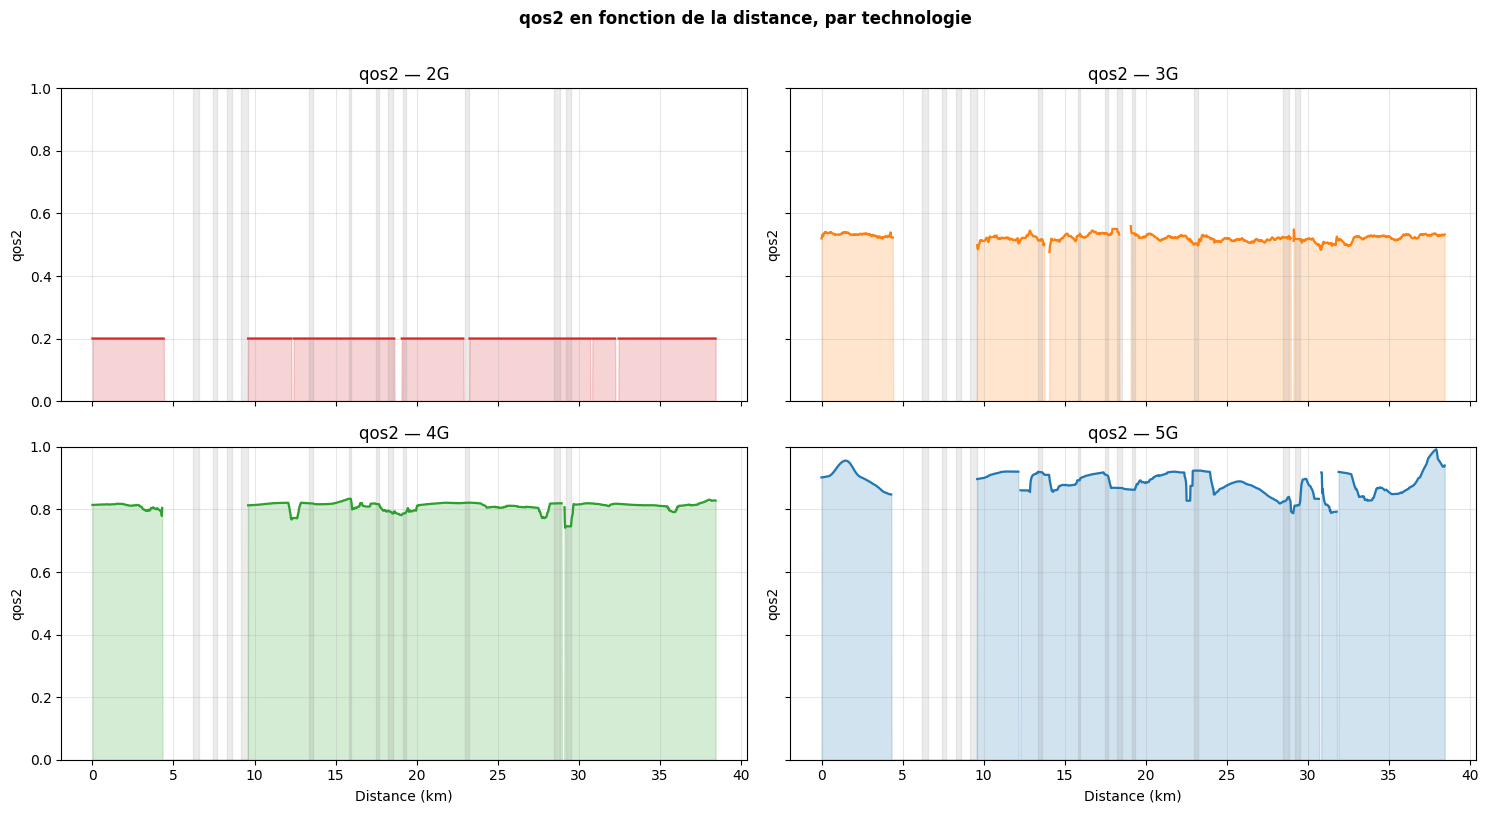

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

for ax, gen in zip(axes.flat, ["2G","3G","4G","5G"]):
    if f"{gen}_smooth" in best_q2.columns:
        ax.plot(best_q2["distance_km"], best_q2[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=1.6)
        ax.fill_between(best_q2["distance_km"], 0,
                        best_q2[f"{gen}_smooth"].fillna(0),
                        color=COLORS_TECH[gen], alpha=0.2)
    for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
        ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
                   color="gray", alpha=0.15)
    ax.set_ylim(0, 1)
    ax.set_title(f"qos2 — {gen}")
    ax.set_ylabel("qos2")
    if gen in ["4G","5G"]:
        ax.set_xlabel("Distance (km)")
    ax.grid(True, alpha=0.3)

plt.suptitle("qos2 en fonction de la distance, par technologie",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 3.c qos1 — toutes technos superposées

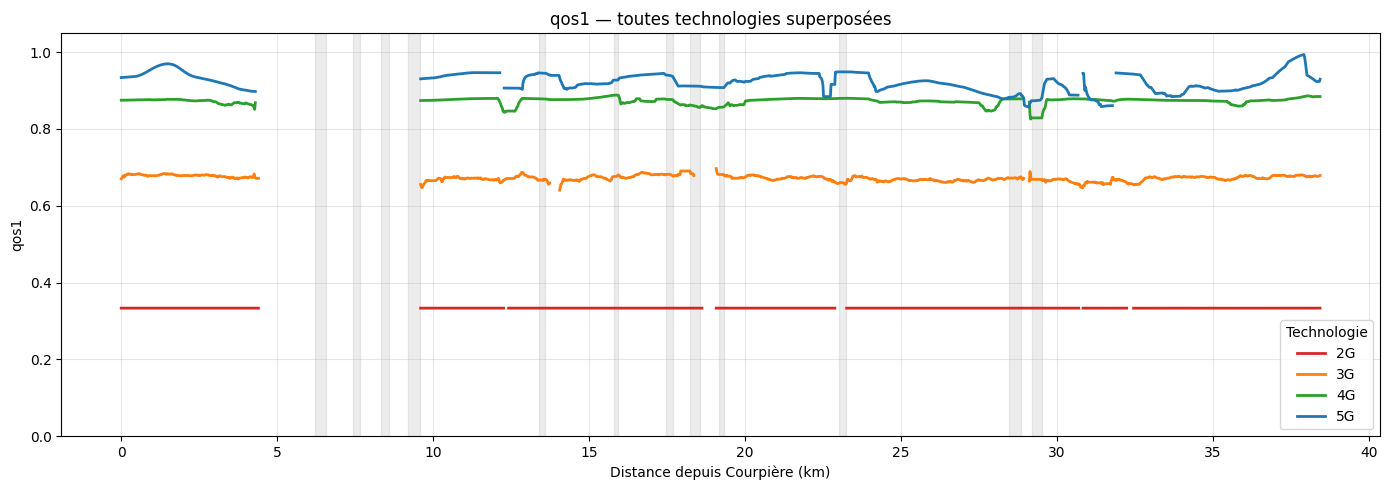

In [105]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q1.columns:
        ax.plot(best_q1["distance_km"], best_q1[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos1")
ax.set_ylim(0, 1.05)
ax.set_title("qos1 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

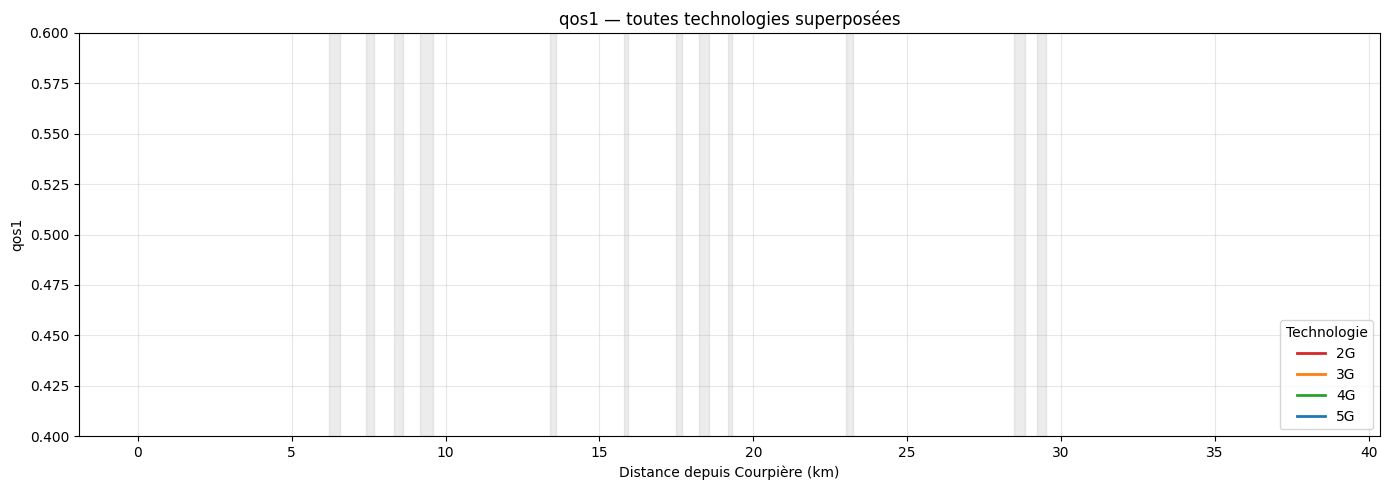

In [106]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q1.columns:
        ax.plot(best_q1["distance_km"], best_q1[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos1")
ax.set_ylim(0.4, 0.6)
ax.set_title("qos1 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

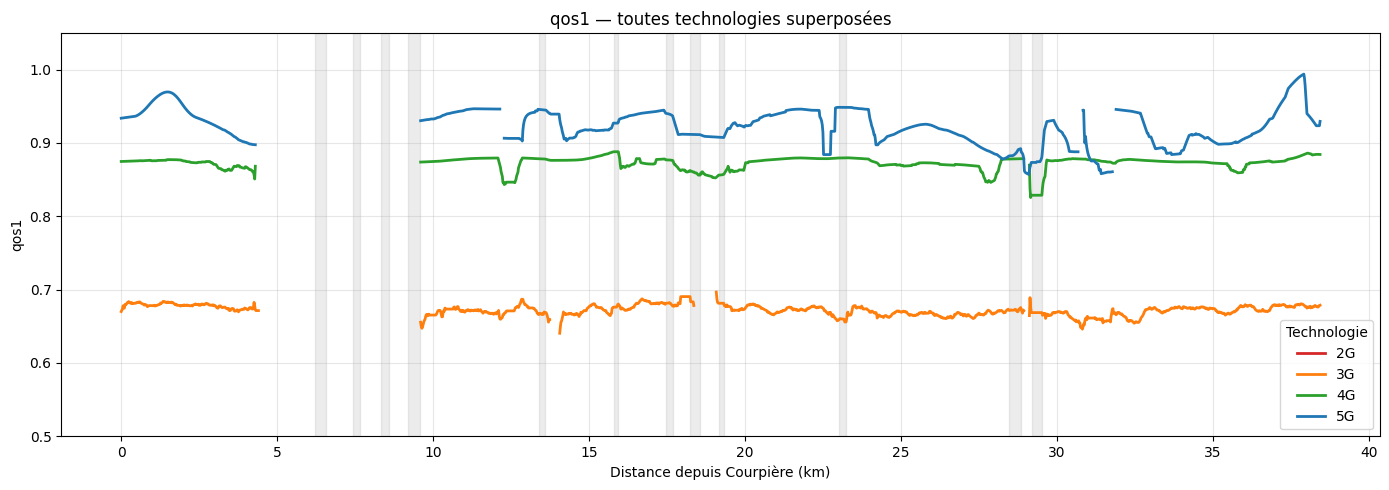

In [107]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q1.columns:
        ax.plot(best_q1["distance_km"], best_q1[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos1")
ax.set_ylim(0.5, 1.05)
ax.set_title("qos1 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

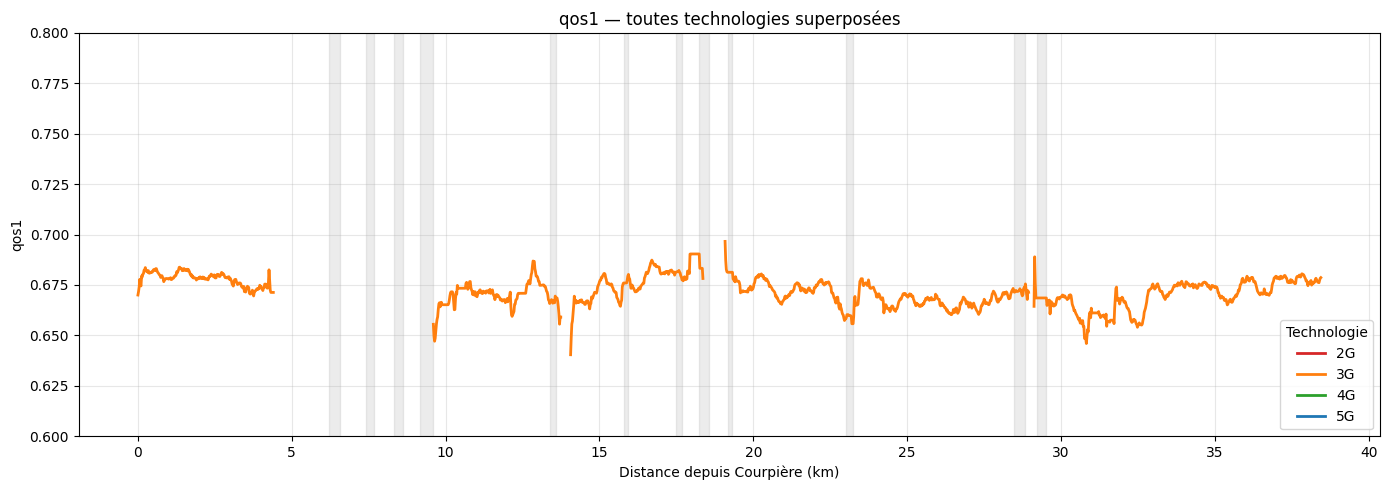

In [108]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q1.columns:
        ax.plot(best_q1["distance_km"], best_q1[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos1")
ax.set_ylim(0.6, 0.8)
ax.set_title("qos1 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.d qos2 — toutes technos superposées

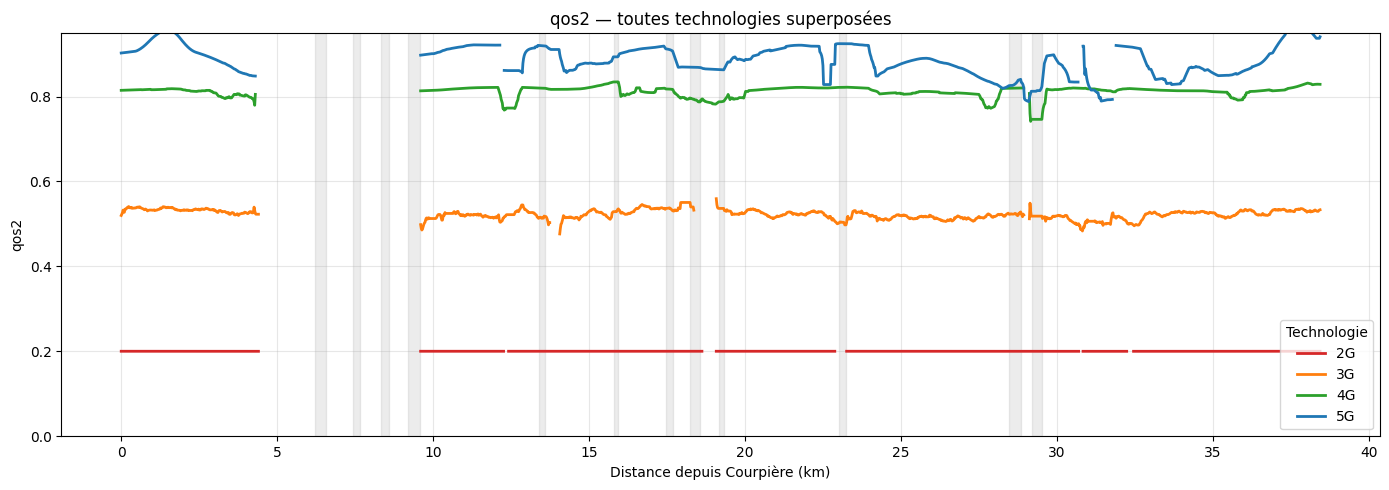

In [109]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q2.columns:
        ax.plot(best_q2["distance_km"], best_q2[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos2")
ax.set_ylim(0, 0.95)
ax.set_title("qos2 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

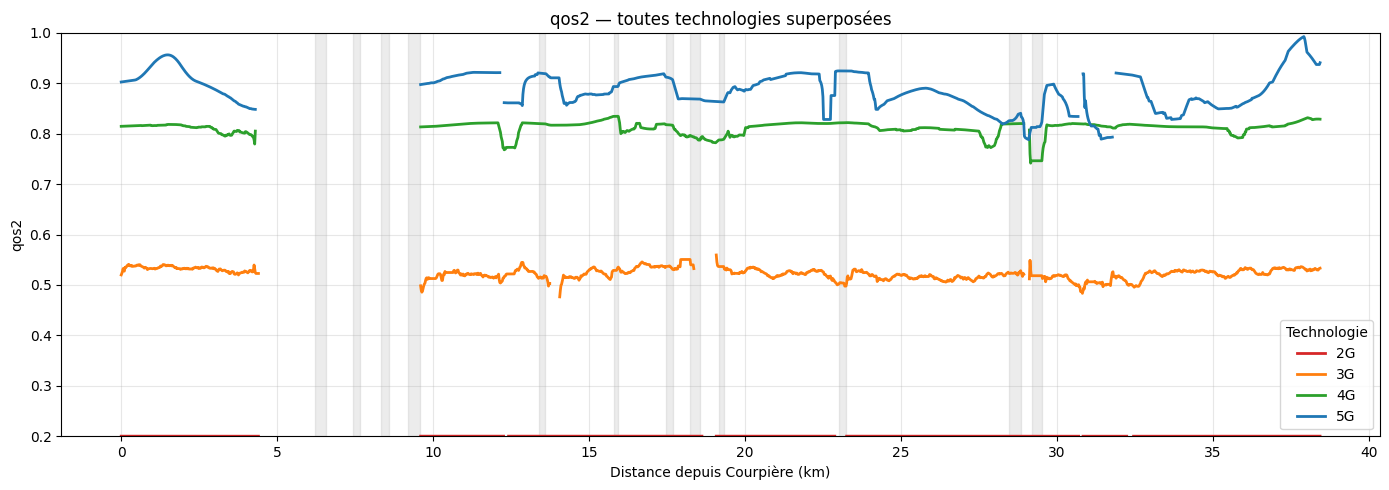

In [126]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q2.columns:
        ax.plot(best_q2["distance_km"], best_q2[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos2")
ax.set_ylim(0.2, 1)
ax.set_title("qos2 — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Lecture des figures QoS**

- **4G et 5G** : les deux saturent à qos1/qos2 ≈ 0.99 sur presque tout le corridor. Leur débit dépasse largement le seuil de satisfaction (`DEBIT_MIN_MBPS = 3 Mbps`), donc le score maximal est atteint dès qu'un lien est disponible.
- **3G** : qos1 médian ≈ 0.77 et qos2 médian ≈ 0.65. Le débit reste bon mais pas maximal — la 3G est "acceptable mais pas excellente" sur la totalité du trajet.
- **2G** : qos1 médian ≈ 0.67 et qos2 médian ≈ 0.52. Elle satisfait la BER (score parfait grâce à la robustesse du GMSK) mais échoue sur le débit et la latence, ce qui tire le score global vers le bas.

**Différence qos1 vs qos2** : les deux courbes ont exactement la même forme, seuls les niveaux absolus varient. qos2 pénalise plus fortement les technos à faible débit (2G, 3G) car elle pondère le débit à 50 % contre 33 % pour qos1 — d'où l'écart plus marqué sur ces deux technos (2G passe de 0.67 en qos1 à 0.52 en qos2, 3G de 0.77 à 0.65). Pour la 4G/5G, les deux scores sont identiques car saturés.

**Conclusion opérationnelle** : sur ce corridor, choisir entre qos1 et qos2 comme label d'apprentissage change à peine les décisions — les deux favorisent la 5G quand elle est là, la 4G partout ailleurs.

3.6 qos3 — toutes technos superposées


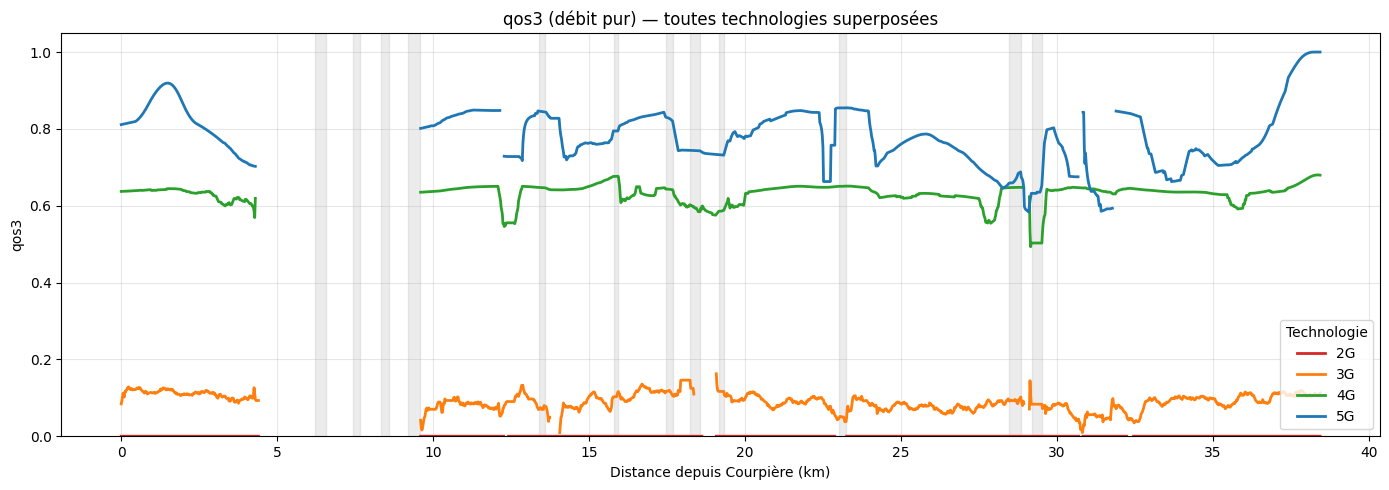

In [117]:
# Recalcul de best_q3 (autonome, indépendant de 3.5)
best_q3 = cel.groupby(["point_id","generation"])["qos3"].max().unstack()
best_q3 = best_q3.reindex(voie["point_id"].values)
best_q3["distance_km"] = voie["distance_km"].values
for gen in ["2G","3G","4G","5G"]:
    if gen in best_q3.columns:
        best_q3[f"{gen}_smooth"] = best_q3[gen].rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_q3.columns:
        ax.plot(best_q3["distance_km"], best_q3[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("qos3")
ax.set_ylim(0, 1.05)
ax.set_title("qos3 (débit pur) — toutes technologies superposées")
ax.legend(title="Technologie", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Lecture qos3 (débit pur)**

Contrairement à qos1 et qos2, qos3 ne dépend que du débit. La hiérarchie technologique devient nette :

- **2G** : qos3 ≈ 0 partout (débit ~0.24 Mbps très en dessous du seuil de référence 300 Mbps)
- **3G** : qos3 très bas (~0.05), le débit 3G stagne à 1-2 Mbps
- **4G** : qos3 ≈ 0.58 en moyenne, entre 0.31 et 0.68
- **5G** : qos3 ≈ 0.75 en moyenne, avec des pics saturés à 1.0 quand le débit dépasse 300 Mbps (140 liens sur 69 852 dans le dataset complet)

qos3 est le score le plus discriminant pour un modèle LTR : il ne masque pas la différence technologique derrière une pondération équilibrée. À utiliser comme label alternatif si on veut que le modèle privilégie explicitement le débit brut.

## 4. Meilleur choix d'antenne à chaque point GPS

Pour chaque point du trajet, on identifie l'antenne qui maximise le QoS. Deux visualisations :
- **4.a Carte spatiale** : chaque point du trajet est colorié selon la technologie de l'antenne optimale à cet endroit.
- **4.b Ligne temporelle** : le QoS de la meilleure antenne choisie, en fonction de la distance parcourue.

C'est exactement le type de décision qu'un modèle Learning-to-Rank apprendra à reproduire.

### 4.a Carte — antenne optimale par point (couleur = technologie)

In [111]:
# Pour chaque point, on identifie la meilleure antenne selon qos1
# (idxmax donne l'index de la ligne — on récupère ensuite ant_id, generation, qos1)
best_idx = cel.groupby("point_id")["qos1"].idxmax()
best_per_point = cel.loc[best_idx, ["point_id","ant_id","generation","qos1","qos2"]]

# On rattache lat/lon depuis voie
best_map = best_per_point.merge(
    voie[["point_id","lat","lon","distance_km"]], on="point_id"
)
best_map.head()

,point_id,ant_id,generation,qos1,qos2,lat,lon,distance_km
0,0,661615.0,5G,0.9336,0.9025,45.765121,3.540238,0.00
1,1,43707.0,5G,0.9339,0.9029,45.764947,3.540304,0.02
2,2,661615.0,5G,0.9341,0.9032,45.764773,3.540371,0.04
3,3,43707.0,5G,0.9343,0.9036,45.764600,3.540437,0.06
4,4,43707.0,5G,0.9346,0.9039,45.764426,3.540504,0.08


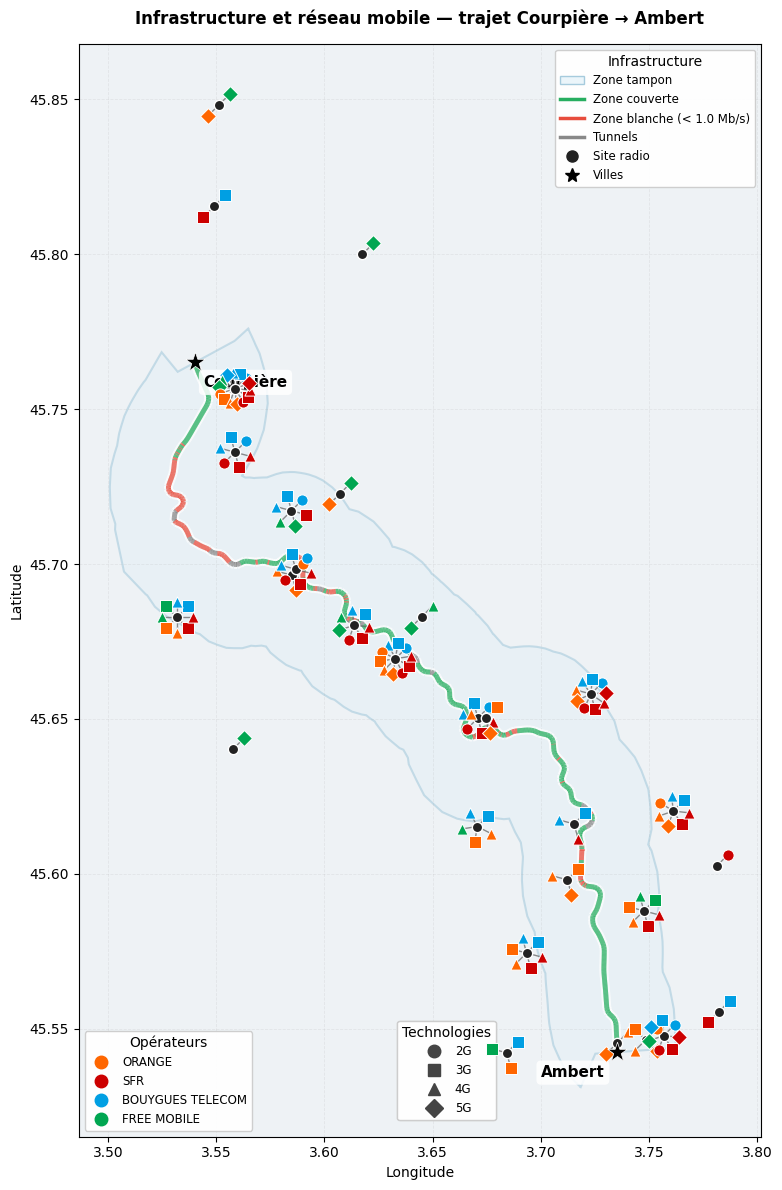

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import LineString

# ─── Paramètres ───
SEUIL_ZONE_BLANCHE = 1.0
COLORS_OP    = {"ORANGE":"#FF6600", "SFR":"#CC0000",
                "BOUYGUES TELECOM":"#009FE3", "FREE MOBILE":"#00A651"}
MARKERS_GEN  = {"2G":"o", "3G":"s", "4G":"^", "5G":"D"}

# ─── Voie ferrée ───
voie = df_s.groupby("point_id").agg(
    lat=("lat","first"), lon=("lon","first"),
    distance_km=("distance_km","first"),
    in_tunnel=("in_tunnel","first"),
    best_debit=("debit_adj_mbps","max"),
).reset_index().sort_values("distance_km").reset_index(drop=True)
voie["etat"] = np.where(voie["in_tunnel"], 2,
                np.where(voie["best_debit"] < SEUIL_ZONE_BLANCHE, 1, 0))
tun_pts = voie[voie["in_tunnel"]]

# ─── Antennes : une ligne par (site, opérateur, techno) ───
ant_raw = (df[df["ant_id"].notna()]
           .groupby("ant_id")
           .agg(ant_lat=("ant_lat","first"), ant_lon=("ant_lon","first"),
                operateur=("operateur","first"), generation=("generation","first"))
           .reset_index())
ant_raw["pos_key"] = (ant_raw["ant_lat"].round(3).astype(str) + "_" +
                      ant_raw["ant_lon"].round(3).astype(str))
antennes = (ant_raw.groupby(["pos_key","operateur","generation"], as_index=False)
                   .agg(ant_lat=("ant_lat","first"), ant_lon=("ant_lon","first")))

# ─── Figure ───
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("#eef2f5")
lat_mean = voie["lat"].mean()
ax.set_aspect(1.0 / np.cos(np.radians(lat_mean)))

# Zone tampon
RAYON_KM = 3.0
buffer_deg = RAYON_KM / 111
ligne_geom  = LineString(list(zip(voie["lon"], voie["lat"])))
zone_tampon = ligne_geom.buffer(buffer_deg, cap_style=2, join_style=2, resolution=8)
polys = zone_tampon.geoms if zone_tampon.geom_type == "MultiPolygon" else [zone_tampon]
for poly in polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, facecolor="#daeef8", edgecolor="#5a9fc0",
            lw=1.5, alpha=0.28, zorder=1)

# Voie ferrée
COLOR_ETAT = {0:"#27ae60", 1:"#e74c3c", 2:"#888888"}
for i in range(len(voie) - 1):
    r1, r2 = voie.iloc[i], voie.iloc[i+1]
    color = COLOR_ETAT[r1["etat"]]
    ax.plot([r1["lon"], r2["lon"]], [r1["lat"], r2["lat"]],
            color="white", lw=6.5, zorder=2, solid_capstyle="butt")
    ax.plot([r1["lon"], r2["lon"]], [r1["lat"], r2["lat"]],
            color=color, lw=3.5, zorder=3, solid_capstyle="butt")

# ─── Antennes : pastille centrale + branches bien espacées ───
aspect   = np.cos(np.radians(lat_mean))
R_BRANCH = 0.005      # longueur des branches (agrandie pour espacer)

for pos_key, group in antennes.groupby("pos_key"):
    clat = group["ant_lat"].iloc[0]
    clon = group["ant_lon"].iloc[0]
    n    = len(group)

    # Pastille centrale = site radio
    ax.scatter(clon, clat, marker="o", color="#222", s=55, zorder=7,
               edgecolors="white", linewidths=1.0)

    # Angles répartis uniformément sur 360°, décalés pour ne pas partir
    # tous vers le bas
    angles = np.linspace(0, 2*np.pi, n, endpoint=False) + np.pi/4

    for idx, (_, row) in enumerate(group.iterrows()):
        bx = clon + (R_BRANCH / aspect) * np.cos(angles[idx])
        by = clat + R_BRANCH * np.sin(angles[idx])
        # Branche
        ax.plot([clon, bx], [clat, by], color="#666", lw=1.0, zorder=5, alpha=0.75)
        # Marqueur (techno = forme, opérateur = couleur)
        ax.scatter(bx, by, marker=MARKERS_GEN[row["generation"]],
                   color=COLORS_OP.get(row["operateur"], "#888"),
                   s=65, zorder=8, edgecolors="white", linewidths=0.7)

# Villes
for ville, i, offset in [("Courpière", 0, (6,-18)), ("Ambert", -1, (-55,-18))]:
    lat, lon = voie.iloc[i]["lat"], voie.iloc[i]["lon"]
    ax.scatter(lon, lat, marker="*", color="black", s=220, zorder=10,
               edgecolors="white", linewidths=0.5)
    ax.annotate(ville, (lon, lat), textcoords="offset points", xytext=offset,
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))

# Légendes séparées
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor="#daeef8", edgecolor="#5a9fc0", label="Zone tampon", alpha=0.5),
    Line2D([0],[0], color="#27ae60", lw=2.5, label="Zone couverte"),
    Line2D([0],[0], color="#e74c3c", lw=2.5, label=f"Zone blanche (< {SEUIL_ZONE_BLANCHE} Mb/s)"),
    Line2D([0],[0], color="#888888", lw=2.5, label="Tunnels"),
    Line2D([0],[0], marker="o", color="#222", linestyle="None", markersize=8, label="Site radio"),
    Line2D([0],[0], marker="*", color="black", linestyle="None", markersize=10, label="Villes"),
], title="Infrastructure", loc="upper right", fontsize=8.5, framealpha=0.95)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[
    Line2D([0],[0], marker="o", color=c, linestyle="None", markersize=9, label=op)
    for op, c in COLORS_OP.items()
], title="Opérateurs", loc="lower left", fontsize=8.5, framealpha=0.95)
ax.add_artist(leg2)

leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color="#444", linestyle="None", markersize=9, label=gen)
    for gen, m in MARKERS_GEN.items()
], title="Technologies", loc="lower right", bbox_to_anchor=(0.62, 0.01),
   fontsize=8.5, framealpha=0.95)
ax.add_artist(leg3)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Infrastructure et réseau mobile — trajet Courpière → Ambert",
             fontweight="bold", pad=14)
ax.grid(True, alpha=0.2, linestyle="--", lw=0.6)
plt.tight_layout()
plt.show()

### 4.b QoS de la meilleure antenne le long du trajet

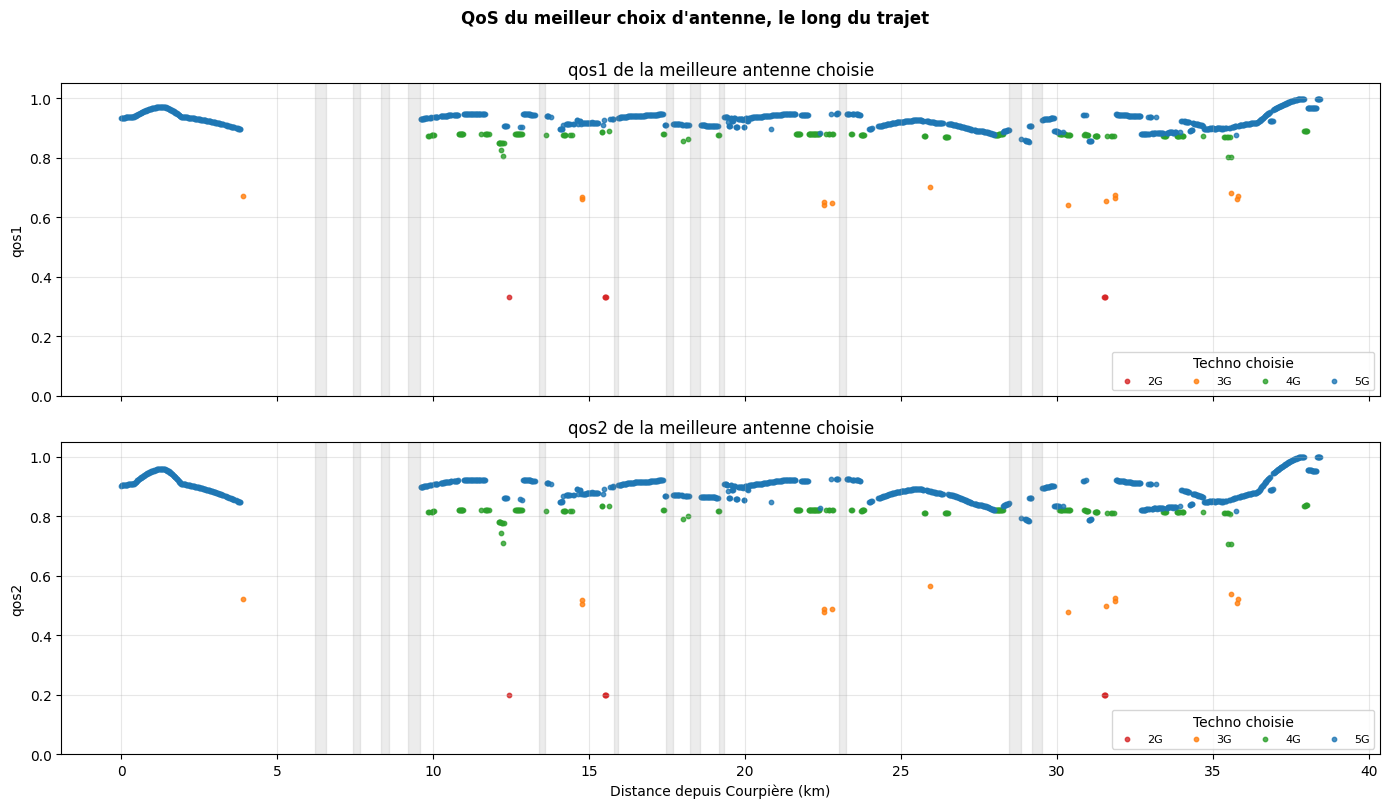

In [113]:
# Alignement sur la distance
best_map_sorted = best_map.sort_values("distance_km")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, score, title in [(axes[0], "qos1", "qos1 de la meilleure antenne choisie"),
                          (axes[1], "qos2", "qos2 de la meilleure antenne choisie")]:
    # Ligne du meilleur score, avec couleur par techno choisie
    for gen in ["2G","3G","4G","5G"]:
        m = best_map_sorted["generation"] == gen
        ax.scatter(best_map_sorted.loc[m,"distance_km"],
                   best_map_sorted.loc[m, score],
                   color=COLORS_TECH[gen], s=10, alpha=0.8, label=gen)

    # Tunnels
    for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
        ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
                   color="gray", alpha=0.15)

    ax.set_ylabel(score)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(title="Techno choisie", loc="lower right", ncol=4, fontsize=8)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Distance depuis Courpière (km)")
plt.suptitle("QoS du meilleur choix d'antenne, le long du trajet",
             fontweight="bold", y=1.005)
plt.tight_layout(); plt.show()

**Interprétation des deux visualisations**

- **La 5G est choisie partout où elle est disponible** : c'est la techno la plus performante en débit, donc elle maximise le QoS presque systématiquement.
- **La 4G prend le relais dans les zones sans 5G** : elle offre elle aussi un QoS saturé (≈1.0) grâce à un débit largement au-dessus du seuil de satisfaction.
- **La 3G et 2G sont choisies uniquement dans les rares points où c'est la seule couverture disponible** — on les voit apparaître ponctuellement en bordure de zone blanche.
- **Les points noirs sur la carte** correspondent aux zones blanches (aucune antenne exploitable) — ce sont les endroits où le train perd toute connectivité.

**Limite honnête à documenter** : comme le QoS sature à 1.0 dès que le débit dépasse 6 Mbps (= 2 × seuil ARCEP de 3 Mbps), une antenne 5G et une antenne 4G proches obtiennent souvent le même score. Le "meilleur choix" est alors décidé par les écarts sur la latence ou le BER, qui peuvent différencier deux liens à débit élevé — ou par le premier arrivé si tout est strictement égal.

## RTT en fonction de la distance

Le RTT est mesuré en millisecondes. Ordre de grandeur très différent selon la génération : ~15 ms en 5G, ~700 ms en 2G. On sépare par techno avec des échelles adaptées, puis on superpose sur une échelle log.

In [118]:
# Meilleur RTT par (point, techno) — on prend le MINIMUM car RTT bas = meilleur
best_rtt = cel.groupby(["point_id","generation"])["rtt_ms"].min().unstack()
best_rtt = best_rtt.reindex(voie["point_id"].values)
best_rtt["distance_km"] = voie["distance_km"].values

# Lissage glissant
window = 25
for gen in ["2G","3G","4G","5G"]:
    if gen in best_rtt.columns:
        best_rtt[f"{gen}_smooth"] = best_rtt[gen].rolling(window, min_periods=1).mean()

best_rtt.head()

generation,2G,3G,4G,5G,distance_km,2G_smooth,3G_smooth,4G_smooth,5G_smooth
point_id,,,,,,,,,
0,679.9,123.7,35.0,18.4,0.00,679.900000,123.700000,35.000000,18.400
1,679.6,123.7,35.0,18.4,0.02,679.750000,123.700000,35.000000,18.400
2,679.4,123.6,34.9,18.4,0.04,679.633333,123.666667,34.966667,18.400
3,679.1,123.6,34.9,18.3,0.06,679.500000,123.650000,34.950000,18.375
4,678.8,123.6,34.8,18.3,0.08,679.360000,123.640000,34.920000,18.360


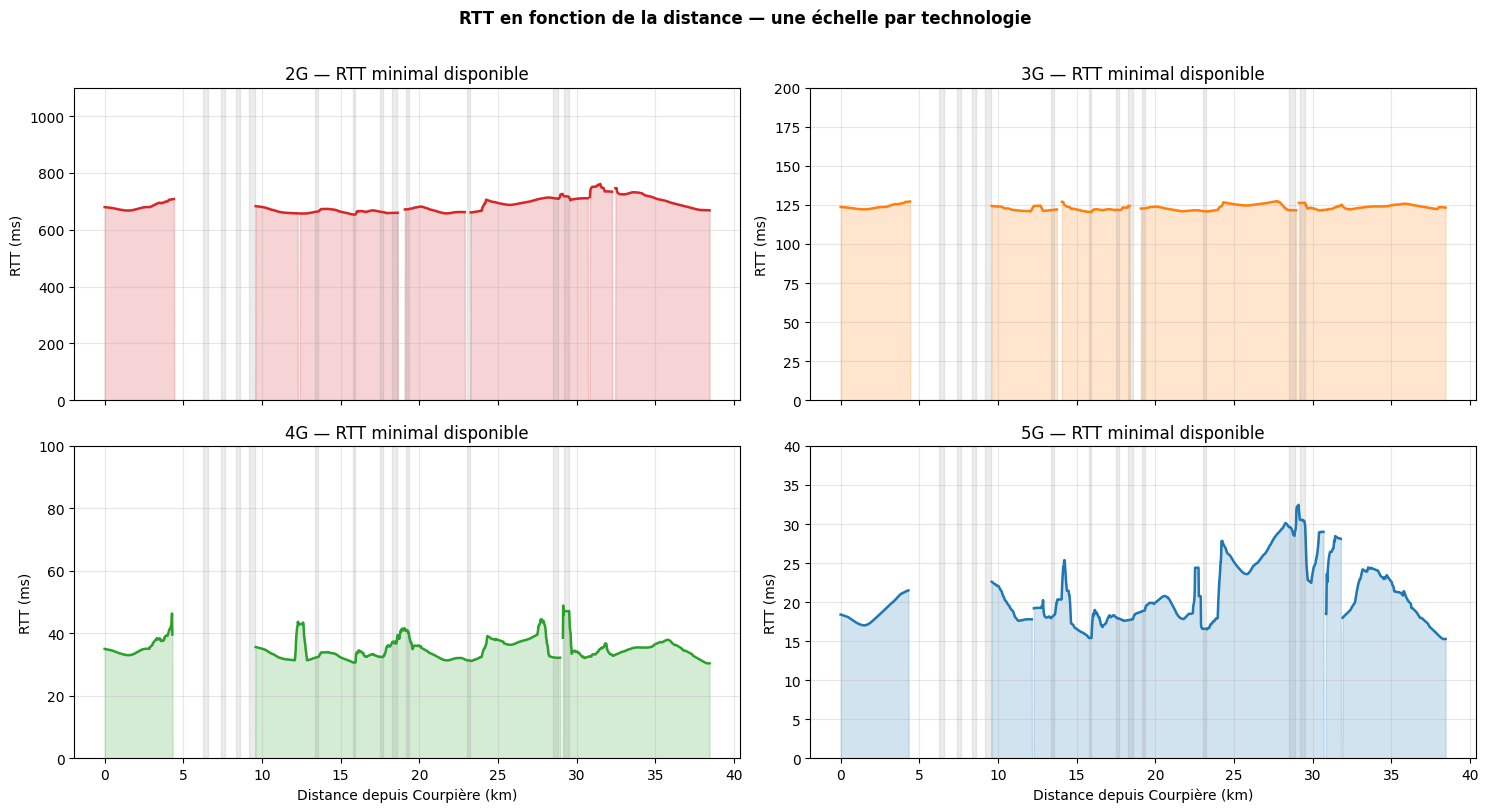

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

# Bornes RTT par techno (issues de TECH_PROFILES)
Y_MAX_RTT = {"2G": 1100, "3G": 200, "4G": 100, "5G": 40}

for ax, gen in zip(axes.flat, ["2G","3G","4G","5G"]):
    if f"{gen}_smooth" in best_rtt.columns:
        ax.plot(best_rtt["distance_km"], best_rtt[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=1.8)
        ax.fill_between(best_rtt["distance_km"], 0,
                        best_rtt[f"{gen}_smooth"].fillna(0),
                        color=COLORS_TECH[gen], alpha=0.2)

    for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
        ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
                   color="gray", alpha=0.15)

    ax.set_ylim(0, Y_MAX_RTT[gen])
    ax.set_title(f"{gen} — RTT minimal disponible")
    ax.set_ylabel("RTT (ms)")
    if gen in ["4G", "5G"]:
        ax.set_xlabel("Distance depuis Courpière (km)")
    ax.grid(True, alpha=0.3)

plt.suptitle("RTT en fonction de la distance — une échelle par technologie",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

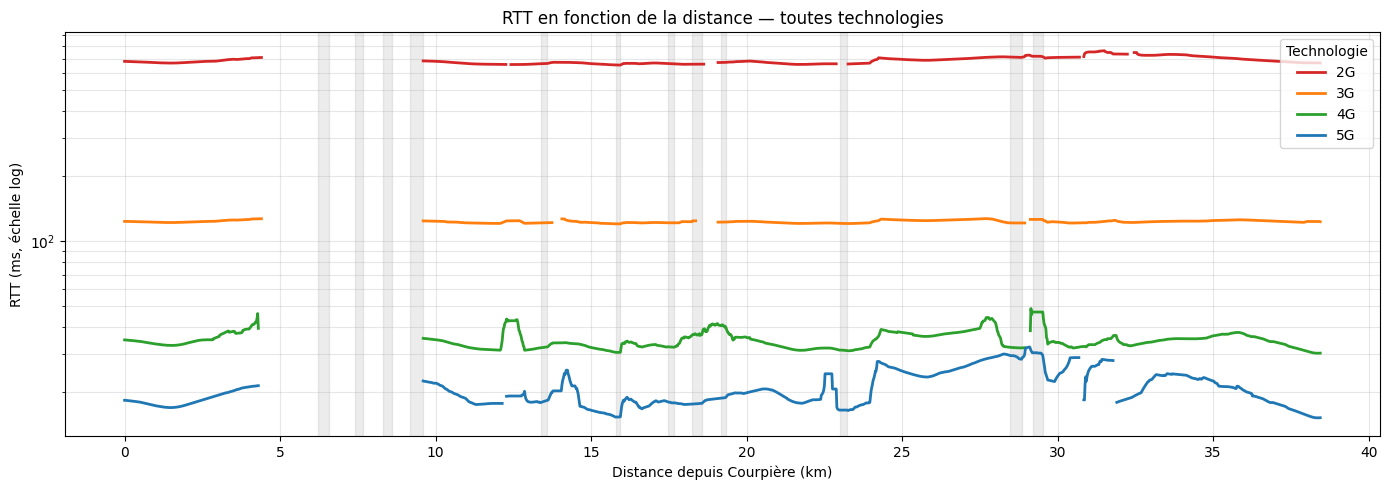

In [120]:
fig, ax = plt.subplots(figsize=(14, 5))
for gen in ["2G","3G","4G","5G"]:
    if f"{gen}_smooth" in best_rtt.columns:
        ax.plot(best_rtt["distance_km"], best_rtt[f"{gen}_smooth"],
                color=COLORS_TECH[gen], lw=2, label=gen)

for _, chunk in tun_pts.groupby((tun_pts["point_id"].diff() != 1).cumsum()):
    ax.axvspan(chunk["distance_km"].min(), chunk["distance_km"].max(),
               color="gray", alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("Distance depuis Courpière (km)")
ax.set_ylabel("RTT (ms, échelle log)")
ax.set_title("RTT en fonction de la distance — toutes technologies")
ax.legend(title="Technologie", loc="upper right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

**Lecture RTT**

- **2G** : RTT autour de 650-1000 ms, incompatible avec toute application temps réel.
- **3G** : RTT stable autour de 120-160 ms, acceptable pour voix + navigation.
- **4G** : RTT entre 30 et 80 ms selon la distance à l'antenne.
- **5G** : RTT entre 15 et 35 ms, seul candidat pour applications critiques ferroviaires (freinage d'urgence, télé-conduite).

Le RTT dépend surtout de la génération et peu de la distance sur ce corridor — les variations le long du trajet sont dues à quelle antenne est la plus proche.





